## Evaluate Trained model
Load trained mode and dataset to evaluate metrics as well as visualize results where required

In [ ]:
!pip install torchmetrics[detection]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.8 MB/s eta 0:00:00


In [ ]:
import os, json

import torchvision.transforms.functional as F
import random

import torch
from PIL import Image
from torch.utils.data import Dataset,DataLoader,Subset

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchvision.models.detection import FasterRCNN
from torchvision.datasets import CocoDetection
from torchvision.ops import box_iou

import torch.optim as optim

from zipfile import ZipFile
import shutil
from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load Dataset

In [ ]:


# Paths
drive_zip_path = '/content/drive/MyDrive/Seminar-XAI-Project/new_dataset2.zip'
local_zip_path = "/content/new_dataset2.zip"
local_extract_path = "/content/new_dataset2"

# Step 1: Copy zip from Drive → local runtime
if not os.path.exists(local_zip_path):
    print("Copying zip file to local runtime...")
    shutil.copy(drive_zip_path, local_zip_path)
    print("Copy complete.")
else:
    print("Zip already exists in local runtime. Skipping copy.")

# Step 2: Extract locally
if not os.path.exists(local_extract_path):
    print("Extracting locally...")
    with ZipFile(local_zip_path, 'r') as zip_ref:
        for file_info in tqdm(zip_ref.infolist(), desc="Extracting files"):
            zip_ref.extract(file_info, local_extract_path)
    print("Extraction complete.")
else:
    print("Already extracted locally. Skipping extraction.")

Copying zip file to local runtime...
Copy complete.
Extracting locally...


Extracting files: 100%|██████████| 12424/12424 [00:04<00:00, 2628.74it/s]

Extraction complete.


In [ ]:
import os

base = "/content/new_dataset2"
categories = ["control", "stress"]
splits = ["train", "val", "test"]

counts = {}

for category in categories:
    counts[category] = {}
    for split in splits:
        path = os.path.join(base, category, "images", split)

        if os.path.exists(path):
            num_files = len([
                f for f in os.listdir(path)
                if f.endswith(".jpg")
            ])
        else:
            num_files = 0

        counts[category][split] = num_files

# ✅ Print nicely
print("\n===== DATASET DISTRIBUTION =====")
total_all = 0

for category in categories:
    print(f"\n{category.upper()}:")
    total_cat = 0

    for split in splits:
        count = counts[category][split]
        print(f"  {split}: {count}")
        total_cat += count

    print(f"  Total ({category}): {total_cat}")
    total_all += total_cat

print(f"\nTOTAL DATASET SIZE: {total_all}")


===== DATASET DISTRIBUTION =====

CONTROL:
  train: 1973
  val: 561
  test: 448
  Total (control): 2982

STRESS:
  train: 2132
  val: 604
  test: 485
  Total (stress): 3221

TOTAL DATASET SIZE: 6203


In [ ]:
DATASET_ROOT = "/content/new_dataset2"

CONTROL_TRAIN_IMGS   = f"{DATASET_ROOT}/control/images/train"
CONTROL_VAL_IMGS     = f"{DATASET_ROOT}/control/images/val"
CONTROL_TEST_IMGS    = f"{DATASET_ROOT}/control/images/test"

CONTROL_TRAIN_LABELS = f"{DATASET_ROOT}/control/labels/train"
CONTROL_VAL_LABELS   = f"{DATASET_ROOT}/control/labels/val"
CONTROL_TEST_LABELS  = f"{DATASET_ROOT}/control/labels/test"

STRESS_TRAIN_IMGS    = f"{DATASET_ROOT}/stress/images/train"
STRESS_VAL_IMGS      = f"{DATASET_ROOT}/stress/images/val"
STRESS_TEST_IMGS     = f"{DATASET_ROOT}/stress/images/test"

STRESS_TRAIN_LABELS  = f"{DATASET_ROOT}/stress/labels/train"
STRESS_VAL_LABELS    = f"{DATASET_ROOT}/stress/labels/val"
STRESS_TEST_LABELS   = f"{DATASET_ROOT}/stress/labels/test"

In [ ]:
import torchvision.transforms.functional as F
import random

class ToTensor:
    def __call__(self, img, target):
        return F.to_tensor(img), target


class RandomHorizontalFlip:
    def __init__(self, prob):
        self.prob = prob

    def __call__(self, img, target):
        if random.random() < self.prob:
            img = F.hflip(img)

            W, _ = img.size  # PIL image size
            boxes = target["boxes"]

            if boxes.shape[0] > 0:
                boxes[:, [0, 2]] = W - boxes[:, [2, 0]]
                target["boxes"] = boxes

        return img, target


class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, target):
        for t in self.transforms:
            img, target = t(img, target)
        return img, target


class RandomVerticalFlip:
    def __init__(self, prob=0.5):
        self.prob = prob
    def __call__(self, img, target):
        if random.random() < self.prob:
            img = F.vflip(img)
            W, H = img.size
            boxes = target["boxes"]
            if boxes.shape[0] > 0:
                boxes[:, [1, 3]] = H - boxes[:, [3, 1]]
                target["boxes"] = boxes
        return img, target

class ColorJitter:
    def __init__(self, brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1):
        self.transform = torchvision.transforms.ColorJitter(brightness, contrast, saturation, hue)
    def __call__(self, img, target):
        img = self.transform(img)
        return img, target

class RandomScale:
    def __init__(self, scales=(0.8, 1.2)):
        self.scales = scales
    def __call__(self, img, target):
        scale = random.uniform(*self.scales)
        W, H = img.size
        new_W, new_H = int(W*scale), int(H*scale)
        img = img.resize((new_W, new_H))
        boxes = target["boxes"]
        if boxes.shape[0] > 0:
            boxes = boxes * scale
            target["boxes"] = boxes
        return img, target
def get_transform(train):
    transforms = []
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
        transforms.append(RandomVerticalFlip(0.2))
        transforms.append(RandomScale((0.8, 1.2)))
        transforms.append(ColorJitter())
    transforms.append(ToTensor())
    return Compose(transforms)

In [ ]:


# Map the string categories from your JSON to integers
# LABEL_MAP = {"background": 0, "pedestrian": 1, "car": 2, "truck": 3, "bus": 3, "rider": 1, "traffic light": 4, "traffic sign": 5}
LABEL_MAP = {"background": 0, "car": 1, "traffic light": 2, "traffic sign": 3}

class PerImageJSONDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.transform = transform

        self.samples = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.lower().endswith(('.jpg', '.png', '.jpeg')):
                continue
            stem = os.path.splitext(fname)[0]
            json_path = os.path.join(label_dir, stem + ".json")
            if os.path.exists(json_path):
                self.samples.append((fname, json_path))

        print(f"Loaded {len(self.samples)} matched image-label pairs from {img_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
          img_fname, json_path = self.samples[idx]
          img_path = os.path.join(self.img_dir, img_fname)
          img = Image.open(img_path).convert("RGB")
          W, H = img.size

          with open(json_path) as f:
              data = json.load(f)

          boxes, labels = [], []

          # Update logic: Navigate the 'frames' -> 'objects' structure
          frames = data.get("frames", [])
          for frame in frames:
              for obj in frame.get("objects", []):
                  cat_name = obj.get("category")
                  label_id = LABEL_MAP.get(cat_name)
                  if label_id is None:
                    continue

                  box = obj.get("box2d")
                  if not box:
                      continue

                  x1, y1, x2, y2 = float(box['x1']), float(box['y1']), float(box['x2']), float(box['y2'])

                  # Clamp to image size
                  x1 = max(0.0, min(x1, W))
                  y1 = max(0.0, min(y1, H))
                  x2 = max(0.0, min(x2, W))
                  y2 = max(0.0, min(y2, H))

                  if x2 - x1 < 1.0 or y2 - y1 < 1.0:
                      continue

                  boxes.append([x1, y1, x2, y2])
                  labels.append(label_id)

          if len(boxes) == 0:
              boxes  = torch.zeros((0, 4), dtype=torch.float32)
              labels = torch.zeros((0,),   dtype=torch.int64)
          else:
              boxes  = torch.tensor(boxes,  dtype=torch.float32)
              labels = torch.tensor(labels, dtype=torch.int64)

          target = {
              "boxes":    boxes,
              "labels":   labels,
              "image_id": torch.tensor([idx]),
          }

          if self.transform:
              img, target = self.transform(img, target)

          return img, target

In [ ]:
# Re-initialize datasets with the new logic
control_train_ds = PerImageJSONDataset(CONTROL_TRAIN_IMGS, CONTROL_TRAIN_LABELS, get_transform(True))
control_val_ds   = PerImageJSONDataset(CONTROL_VAL_IMGS,   CONTROL_VAL_LABELS,   get_transform(False))
control_test_ds  = PerImageJSONDataset(CONTROL_TEST_IMGS,  CONTROL_TEST_LABELS,  get_transform(False))
stress_test_ds   = PerImageJSONDataset(STRESS_TEST_IMGS,   STRESS_TEST_LABELS,   get_transform(False))



Loaded 1973 matched image-label pairs from /content/new_dataset2/control/images/train
Loaded 561 matched image-label pairs from /content/new_dataset2/control/images/val
Loaded 448 matched image-label pairs from /content/new_dataset2/control/images/test
Loaded 485 matched image-label pairs from /content/new_dataset2/stress/images/test


In [ ]:
BATCH_SIZE=32

# Re-create loaders
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(control_train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(control_val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(control_test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

stress_test_loader=DataLoader(stress_test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


Load model

In [ ]:


# Paths
# saved_model_path = '/content/drive/MyDrive/Seminar-XAI-Project/model_epoch18_ds2.pth'
saved_model_path = '/content/drive/MyDrive/Seminar-XAI-Project/model_epoch12_ds2_best.pth'
local_model_path = "/content/model_epoch12_ds2_best.pth"


# Step 1: Copy model from Drive → local runtime
if not os.path.exists(local_model_path):
    print("Copying saved model to local runtime...")
    shutil.copy(saved_model_path, local_model_path)
    print("Copy complete.")
else:
    print("Model already exists in local runtime. Skipping copy.")


Copying saved model to local runtime...
Copy complete.


In [ ]:


# def get_model(num_classes):
#     # Load a model pre-trained on COCO
#     model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')

#     # Replace the classifier with a new one, that has 'num_classes' which includes the background
#     in_features = model.roi_heads.box_predictor.cls_score.in_features
#     model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

#     return model

def get_model(num_classes):
    # Load a model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT',  min_size=1000,   # 👈 KEY CHANGE
    max_size=1600)

    # Replace the classifier with a new one, that has 'num_classes' which includes the background
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


In [ ]:


# 1. Recreate model architecture
num_classes=4
model = get_model(num_classes=num_classes)


# 2. Load checkpoint
checkpoint = torch.load("/content/model_epoch12_ds2_best.pth", map_location="cuda")  # or "cuda"

# 3. Load weights
model.load_state_dict(checkpoint["model_state_dict"])

# 4. Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 5. Set to evaluation mode
model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 183MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(1000,), max_size=1600, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU

In [ ]:
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def evaluate_detection_map(model, data_loader, device):
    """
    Evaluate a detection model using mAP (mean Average Precision)
    Args:
        model: torch detection model
        data_loader: DataLoader with batches of (imgs, targets)
        device: cuda or cpu
    """
    model.eval()
    metric = MeanAveragePrecision(class_metrics=True)

    for imgs, targets in data_loader:
        imgs = [img.to(device) for img in imgs]
        # keep targets on CPU for torchmetrics
        targets_cpu = [{k: v.cpu() for k,v in t.items()} for t in targets]

        outputs = model(imgs)
        # move outputs to CPU
        outputs_cpu = [{k: v.cpu() for k,v in out.items()} for out in outputs]

        metric.update(outputs_cpu, targets_cpu)

    results = metric.compute()
    print("mAP @ IoU=0.50:0.95 ->", results["map"].item())
    print("mAP @ IoU=0.50      ->", results["map_50"].item())
    print("mAP @ IoU=0.75      ->", results["map_75"].item())
    print("mAP per class:", results["map_per_class"].tolist())
    return results

In [ ]:
print("Evaluating on Control Test Set...")
ctrl_res = evaluate_detection_map(model, test_loader, device=device)

print("Evaluating on Stress Test Set...")
stress_res = evaluate_detection_map(model, stress_test_loader, device=device)

print(f"\nControl mAP: {ctrl_res['map'].item():.4f}")
print(f"Stress mAP: {stress_res['map'].item():.4f}")
print(f"Performance Drop: {ctrl_res['map'].item() - stress_res['map'].item():.4f}")

Evaluating on Control Test Set...
mAP @ IoU=0.50:0.95 -> 0.29417869448661804
mAP @ IoU=0.50      -> 0.6015426516532898
mAP @ IoU=0.75      -> 0.24845735728740692
mAP per class: [0.4171954095363617, 0.19470730423927307, 0.27063339948654175]
Evaluating on Stress Test Set...
mAP @ IoU=0.50:0.95 -> 0.26816290616989136
mAP @ IoU=0.50      -> 0.5619143843650818
mAP @ IoU=0.75      -> 0.224993497133255
mAP per class: [0.38880476355552673, 0.16152538359165192, 0.25415855646133423]

Control mAP: 0.2942
Stress mAP: 0.2682
Performance Drop: 0.0260


In [ ]:
import torch
import numpy as np
from collections import defaultdict

def box_iou(box1, box2):
    # box: [x1, y1, x2, y2]
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter = max(0, xB - xA) * max(0, yB - yA)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter + 1e-6
    return inter / union


def match_predictions(pred_boxes, pred_labels, pred_scores,
                      gt_boxes, gt_labels,
                      iou_thresh=0.5):

    matched_gt = set()
    tp, fp = 0, 0

    iou_list = []
    correct_cls = 0
    total_matched = 0

    # sort predictions by confidence
    idxs = np.argsort(-pred_scores)

    for i in idxs:
        pb = pred_boxes[i]
        pl = pred_labels[i]

        best_iou = 0
        best_j = -1

        for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
            if j in matched_gt:
                continue

            iou = box_iou(pb, gb)

            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= iou_thresh and best_j != -1:
            tp += 1
            matched_gt.add(best_j)

            iou_list.append(best_iou)
            total_matched += 1

            if pl == gt_labels[best_j]:
                correct_cls += 1

        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "iou_list": iou_list,
        "cls_acc": correct_cls / max(total_matched, 1)
    }
def evaluate_faster_rcnn(model, data_loader, device, score_thresh=0.5):
    model.eval()

    all_iou = []
    total_tp = total_fp = total_fn = 0
    cls_accs = []

    with torch.no_grad():
        for imgs, targets in data_loader:
            imgs = [img.to(device) for img in imgs]

            outputs = model(imgs)

            for out, tgt in zip(outputs, targets):

                # Faster R-CNN format cleanup
                pred_boxes = out["boxes"].cpu().numpy()
                pred_scores = out["scores"].cpu().numpy()
                pred_labels = out["labels"].cpu().numpy()

                # filter low confidence
                keep = pred_scores >= score_thresh
                pred_boxes = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]

                gt_boxes = tgt["boxes"].cpu().numpy()
                gt_labels = tgt["labels"].cpu().numpy()

                res = match_predictions(
                    pred_boxes, pred_labels, pred_scores,
                    gt_boxes, gt_labels
                )

                total_tp += res["tp"]
                total_fp += res["fp"]
                total_fn += res["fn"]

                all_iou.extend(res["iou_list"])
                cls_accs.append(res["cls_acc"])

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    mean_iou = np.mean(all_iou) if len(all_iou) > 0 else 0
    mean_cls_acc = np.mean(cls_accs)

    print("\n===== DETECTION BREAKDOWN =====")
    print("Precision:", precision)
    print("Recall:", recall)
    print("Mean IoU:", mean_iou)
    print("Classification Accuracy (matched boxes):", mean_cls_acc)

    return {
        "precision": precision,
        "recall": recall,
        "mean_iou": mean_iou,
        "cls_acc": mean_cls_acc,
        "iou_distribution": all_iou
    }

In [ ]:
control_stats = evaluate_faster_rcnn(model, test_loader, device)
stress_stats  = evaluate_faster_rcnn(model, stress_test_loader, device)


===== DETECTION BREAKDOWN =====
Precision: 0.5873525030831306
Recall: 0.6835088653934797
Mean IoU: 0.7643712
Classification Accuracy (matched boxes): 0.9867893304172084

===== DETECTION BREAKDOWN =====
Precision: 0.5326468257856006
Recall: 0.6529338326185415
Mean IoU: 0.75462204
Classification Accuracy (matched boxes): 0.9808285582905143


In [ ]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import FasterRCNNBoxScoreTarget
import numpy as np, matplotlib.pyplot as plt, cv2
import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 119.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


--- Grad-CAM: Control Sample ---


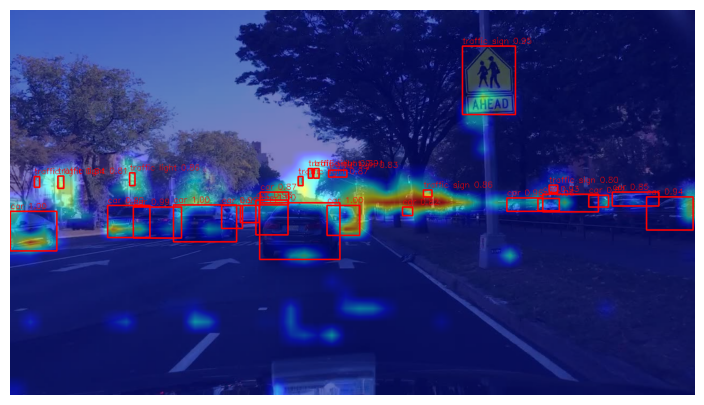

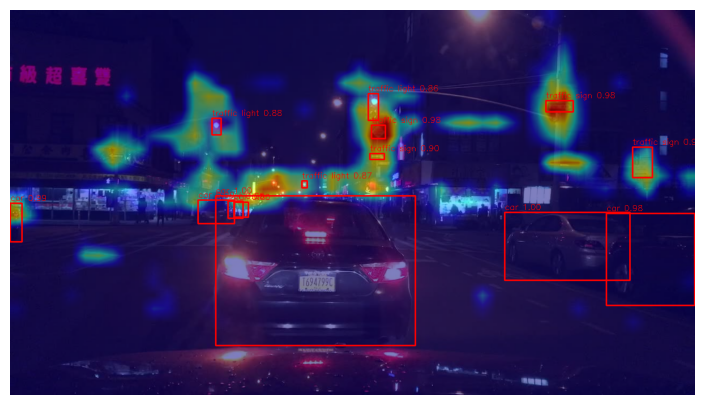

--- Grad-CAM: Stress Sample ---


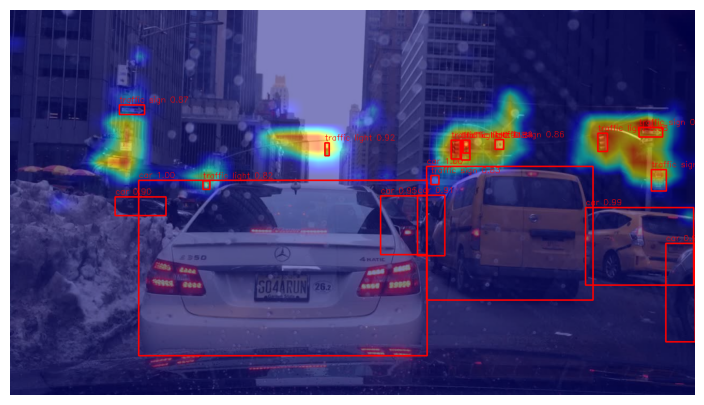

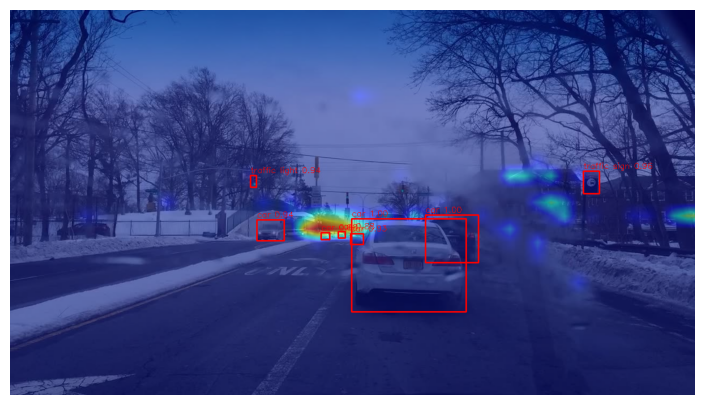

In [ ]:


# Define target layer for Faster R-CNN (usually the last layer of the backbone)
target_layer = [model.backbone.body.layer4[-1]]

# target_layer = [model.backbone.body.layer3[-1]]  # more spatial detail
cam = GradCAM(model=model, target_layers=target_layer)

REVERSE_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

def show_gradcam(img_tensor, save_name):
    model.eval()
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(input_tensor)

    preds = outputs[0]
    score_threshold = 0.8 # Threshold to filter weak detections
    high_conf_indices = torch.where(preds['scores'] > score_threshold)[0]

    if high_conf_indices.numel() == 0:
        print(f"No detections above {score_threshold} for {save_name}. Showing raw image.")
        plt.imshow(img_tensor.permute(1,2,0).cpu().numpy()); plt.axis('off'); plt.show()
        return

    # Target the highest scoring detection
    top_idx = high_conf_indices[torch.argmax(preds['scores'][high_conf_indices])]
    # targets = [FasterRCNNBoxScoreTarget(labels=preds['labels'][top_idx:top_idx+1],bounding_boxes=preds['boxes'][top_idx:top_idx+1])]
    targets = [FasterRCNNBoxScoreTarget(labels=preds['labels'][high_conf_indices],bounding_boxes=preds['boxes'][high_conf_indices])]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # ---- draw bounding boxes ----
    img_with_boxes = cam_image.copy()

    for i in high_conf_indices:
        box = preds['boxes'][i].detach().cpu().numpy().astype(int)
        label = preds['labels'][i].item()
        score = preds['scores'][i].item()

        x1, y1, x2, y2 = box

        # draw rectangle
        cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), (255, 0, 0), 2)

        # label text
        text = f"{REVERSE_LABEL_MAP.get(label, 'obj')} {score:.2f}"
        cv2.putText(img_with_boxes, text, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    plt.figure(figsize=(10,5))
    plt.imshow(img_with_boxes)
    # plt.title(f"Grad-CAM: {REVERSE_LABEL_MAP.get(preds['labels'][top_idx].item(), 'object')}")

    plt.axis('off')
    plt.show()

print("--- Grad-CAM: Control Sample ---")
show_gradcam(control_test_ds[98][0], "control_cam.png")
show_gradcam(control_test_ds[10][0], "control_cam.png")

print("--- Grad-CAM: Stress Sample ---")
show_gradcam(stress_test_ds[484][0], "stress_cam.png")
show_gradcam(stress_test_ds[483][0], "stress_cam.png")
# show_gradcam(stress_test_ds[976][0], "stress_cam.png")

In [ ]:
def show_gradcam(img_tensor, save_name):
    model.eval()
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # ---- Forward pass ----
    with torch.no_grad():
        outputs = model(input_tensor)

    preds = outputs[0]
    score_threshold = 0.8
    high_conf_indices = torch.where(preds['scores'] > score_threshold)[0]

    if high_conf_indices.numel() == 0:
        print(f"No detections above {score_threshold} for {save_name}. Showing raw image.")
        plt.imshow(img_tensor.permute(1,2,0).cpu().numpy())
        plt.axis('off')
        plt.show()
        return

    # ---- CAM target (all high confidence boxes) ----
    targets = [
        FasterRCNNBoxScoreTarget(
            labels=preds['labels'][high_conf_indices],
            bounding_boxes=preds['boxes'][high_conf_indices]
        )
    ]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # ---- image ----
    img_np = img_tensor.permute(1,2,0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)

    h, w = img_np.shape[:2]
    cam_resized = cv2.resize(grayscale_cam, (w, h))

    cam_image = show_cam_on_image(img_np, cam_resized, use_rgb=True)

    # =========================
    # Draw boxes on BOTH images
    # =========================
    def draw_boxes(image):
        out = image.copy()
        for i in high_conf_indices:
            box = preds['boxes'][i].detach().cpu().numpy().astype(int)
            label = preds['labels'][i].item()
            score = preds['scores'][i].item()

            x1, y1, x2, y2 = box

            cv2.rectangle(out, (x1, y1), (x2, y2), (255, 0, 0), 2)

            text = f"{REVERSE_LABEL_MAP.get(label, 'obj')} {score:.2f}"
            cv2.putText(out, text, (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
        return out

    img_boxes = draw_boxes(img_np)
    # cam_boxes = draw_boxes(cam_image)

    # =========================
    # Plot side-by-side
    # =========================
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(img_boxes)
    axs[0].set_title("Original + Boxes")
    axs[0].axis("off")

    axs[1].imshow(cam_image)
    axs[1].set_title("Grad-CAM")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


--- Grad-CAM: Control Sample ---


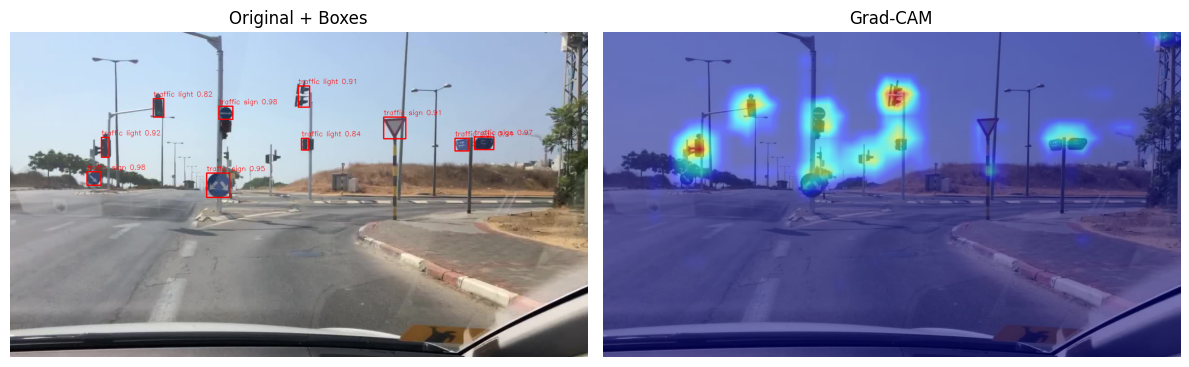

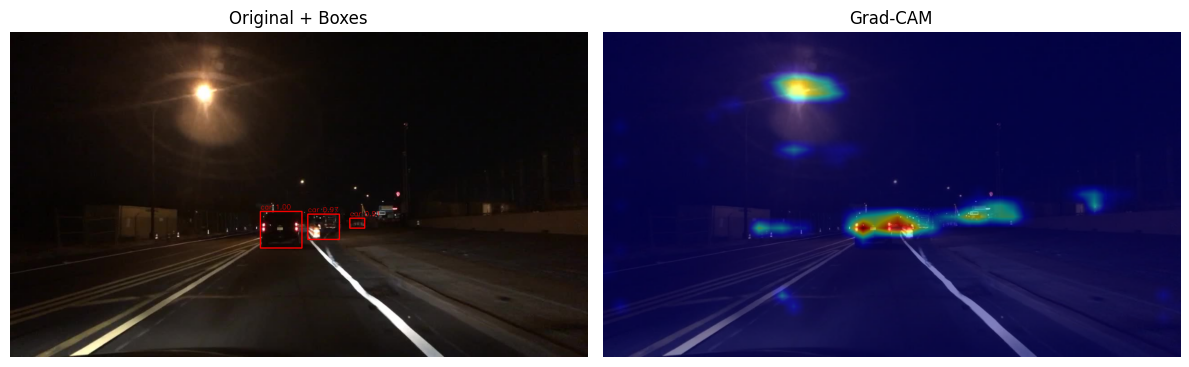

--- Grad-CAM: Stress Sample ---


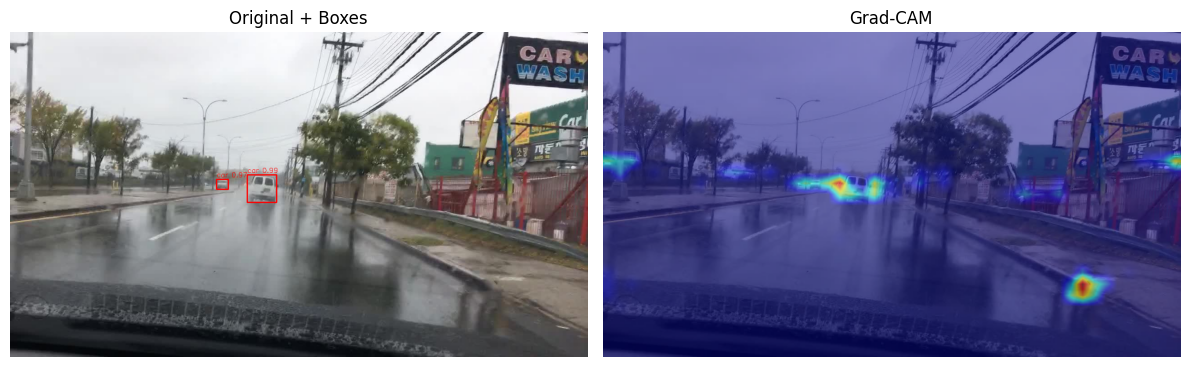

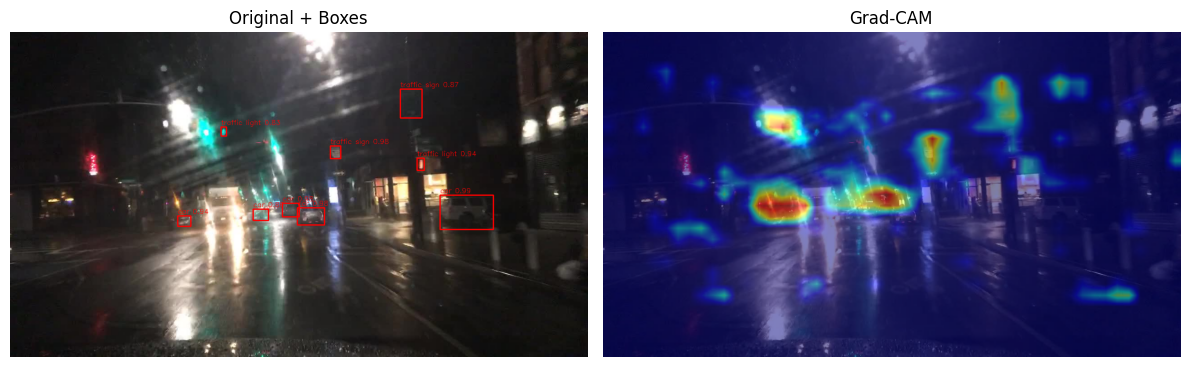

In [ ]:
print("--- Grad-CAM: Control Sample ---")
show_gradcam(control_test_ds[11][0], "control_cam.png")
show_gradcam(control_test_ds[17][0], "control_cam.png")

print("--- Grad-CAM: Stress Sample ---")
show_gradcam(stress_test_ds[3][0], "stress_cam.png")
show_gradcam(stress_test_ds[4][0], "stress_cam.png")
# show_gradcam(stress_test_ds[976][0], "stress_cam.png")

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import FasterRCNNBoxScoreTarget
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch

target_layer = [model.backbone.body.layer4[-1]]  # better spatial resolution

cam = GradCAM(model=model, target_layers=target_layer)

CAR_LABEL_ID = 1  # change if needed

def show_topk_gradcam(img_tensor, k=3, score_thresh=0.3, only_cars=True):

    model.eval()
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # ---- Forward pass ----
    with torch.no_grad():
        outputs = model(input_tensor)

    preds = outputs[0]
    scores = preds['scores']
    labels = preds['labels']
    boxes = preds['boxes']

    # ---- Filter detections ----
    # keep = (scores > score_thresh) & (scores < 1)
    keep = (scores > score_thresh)
    if only_cars:
        keep = keep & (labels == CAR_LABEL_ID)

    indices = torch.where(keep)[0]

    if indices.numel() == 0:
        print("No valid detections")
        return

    # ---- Select top-k ----
    topk_indices = indices[torch.argsort(scores[indices], descending=True)[:k]]

    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = np.clip(img_np, 0, 1)

    # +1 for original image
    fig, axs = plt.subplots(1, len(topk_indices) + 1, figsize=(5 * (len(topk_indices) + 1), 5))

    if len(axs) == 1:
        axs = [axs]

    # ---- 1. Show ORIGINAL IMAGE ----
    axs[0].imshow(img_np)
    axs[0].set_title("Original Image")
    axs[0].axis("off")

    # ---- Loop over each detection ----
    for ax, idx in zip(axs[1:], topk_indices):

        label = labels[idx:idx+1]
        box = boxes[idx:idx+1]

        # ---- Grad-CAM target (SINGLE ROI) ----
        target = FasterRCNNBoxScoreTarget(
            labels=label,
            bounding_boxes=box
        )

        grayscale_cam = cam(input_tensor=input_tensor, targets=[target])[0]

        # ---- Resize CAM ----
        h, w = img_np.shape[:2]
        cam_resized = cv2.resize(grayscale_cam, (w, h))

        # ---- Overlay CAM ----
        cam_image = show_cam_on_image(img_np, cam_resized, use_rgb=True)

        # ---- Draw bounding box ----
        x1, y1, x2, y2 = box[0].detach().cpu().numpy().astype(int)
        cv2.rectangle(cam_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        ax.imshow(cam_image)
        ax.set_title(f"Score: {scores[idx]:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

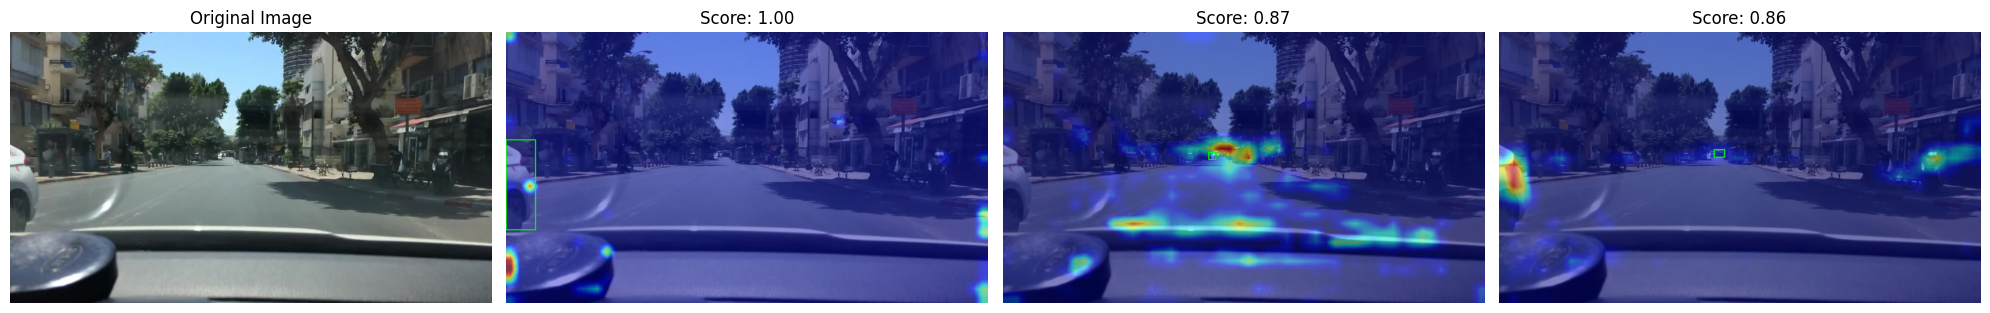

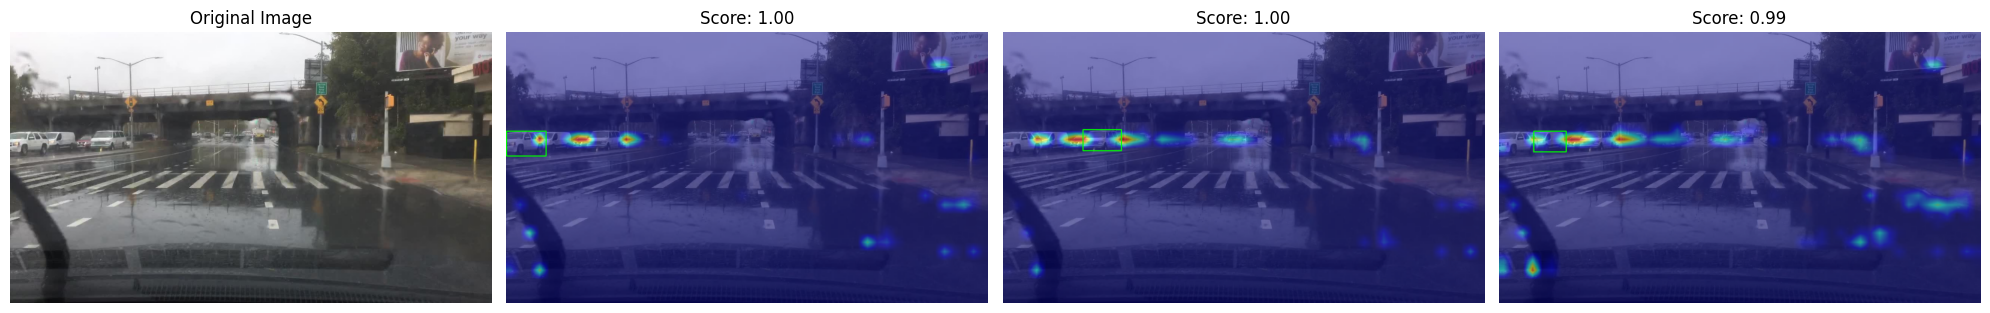

In [ ]:
i=15
show_topk_gradcam(control_test_ds[i][0])
j=25
show_topk_gradcam(stress_test_ds[j][0])

DRISE

In [ ]:
import torch
import numpy as np
import cv2
from tqdm import tqdm

# -----------------------------
# Utility: generate random masks
# -----------------------------
def generate_random_masks(H, W, N=200, p=0.5, mask_size=64):
    """
    Generates random rectangular masks (RISE-style)
    """
    masks = np.zeros((N, H, W), dtype=np.float32)

    for i in range(N):
        mask = np.ones((H, W), dtype=np.float32)

        for _ in range(np.random.randint(1, 5)):
            x = np.random.randint(0, W)
            y = np.random.randint(0, H)
            w = np.random.randint(mask_size // 2, mask_size)
            h = np.random.randint(mask_size // 2, mask_size)

            x1, y1 = max(0, x - w // 2), max(0, y - h // 2)
            x2, y2 = min(W, x + w // 2), min(H, y + h // 2)

            mask[y1:y2, x1:x2] = 0

        masks[i] = mask

    return masks

def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    return inter / (area1 + area2 - inter + 1e-6)

# -----------------------------
# D-RISE main function
# -----------------------------
@torch.no_grad()
def drise_fasterrcnn(
    model,
    img_tensor,
    device,
    target_box_idx=0,
    num_masks=200,
    score_thresh=0.3
):
    """
    D-RISE for a single detection (box-level explanation)
    """

    model.eval()

    img = img_tensor.to(device)
    C, H, W = img.shape

    # -----------------------------
    # 1. Get baseline prediction
    # -----------------------------
    pred = model([img])[0]

    if len(pred["scores"]) <= target_box_idx:
        print(f"Warning: Not enough detections for target_box_idx={target_box_idx}. Returning empty heatmap.")
        return np.zeros((H, W)), None

    # pick target detection
    scores = pred["scores"]
    idx = int(torch.argsort(scores, descending=True)[target_box_idx])

    target_score = scores[idx].item()
    target_box = pred["boxes"][idx].cpu().numpy()

    # -----------------------------
    # 2. Generate random masks
    # -----------------------------
    masks = generate_random_masks(H, W, N=num_masks)

    importance_map = np.zeros((H, W), dtype=np.float32)
    mask_count = np.zeros((H, W), dtype=np.float32)

    # -----------------------------
    # 3. Monte Carlo evaluation
    # -----------------------------
    for m in tqdm(masks, desc="D-RISE"):

        m_tensor = torch.from_numpy(m).to(device)

        masked_img = img * m_tensor # m=0 means occluded, m=1 means visible

        out = model([masked_img])[0]

        if len(out["scores"]) == 0:
            continue

        best_iou = 0
        best_score_m = 0.0

        for j in range(len(out["boxes"])):
            box_m = out["boxes"][j].cpu().numpy()
            score_m = out["scores"][j].item()

            iou_val = iou(target_box, box_m)

            if iou_val > best_iou:
                best_iou = iou_val
                best_score_m = score_m

        # -----------------------------
        # contribution signal
        # -----------------------------
        # If target_score - best_score_m is positive, it means masking *decreased*
        # the score, implying the *masked out region* was important.
        # We apply this delta to the occluded part of the mask (1 - m).
        delta = best_iou * (target_score - best_score_m)
        # delta =(target_score - best_score_m)

        # accumulate importance
        importance_map += (1 - m) * delta
        mask_count += (1 - m)

    # -----------------------------
    # 4. Normalize
    # -----------------------------
    mask_count[mask_count == 0] = 1.0
    importance_map = importance_map / mask_count

    # normalize to [0,1]
    importance_map = np.maximum(importance_map, 0)
    if importance_map.max() > 0:
        importance_map = importance_map / (importance_map.max() + 1e-8)

    return importance_map, target_box

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_drise(img_tensor, heatmap):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap="jet", alpha=0.5)
    plt.axis("off")
    plt.show()

In [ ]:
import matplotlib.pyplot as plt

def show_results(img_tensor, pred_box, heatmap):
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = np.clip(img, 0, 1)

    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap((heatmap_resized*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = (0.6 * (img*255) + 0.4 * heatmap_color).astype(np.uint8)

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    # original
    axs[0].imshow(img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    # boxes
    img_boxes = (img*255).astype(np.uint8).copy()


    if pred_box is not None:
        x1,y1,x2,y2 = pred_box.astype(int)
        cv2.rectangle(img_boxes, (x1,y1), (x2,y2), (255,0,0), 2)

    axs[1].imshow(img_boxes)
    axs[1].set_title("GT (green) + Pred (red)")
    axs[1].axis("off")

    # heatmap overlay
    axs[2].imshow(overlay)
    axs[2].set_title("D-RISE Heatmap")
    axs[2].axis("off")

    plt.show()

D-RISE: 100%|██████████| 300/300 [00:06<00:00, 48.66it/s]


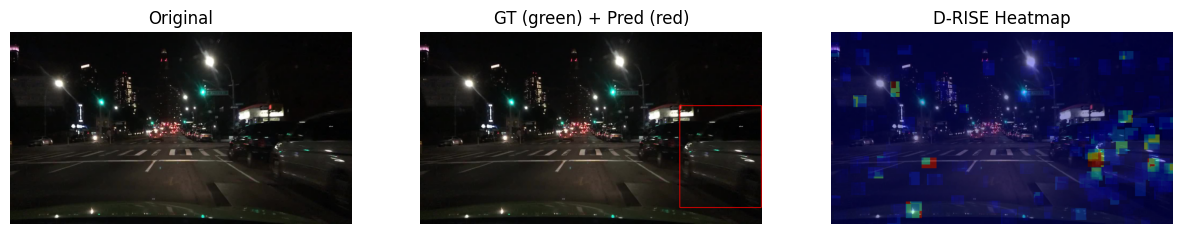

In [ ]:
idx=30
img, _ = control_test_ds[idx]

heatmap, box = drise_fasterrcnn(
    model,
    img,
    device,
    target_box_idx=0,
    num_masks=300
)

show_results(img, box, heatmap)